In [40]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from aicsimageio import AICSImage, imread
from skimage.draw import polygon, disk, rectangle
from skimage import io, img_as_float
from scipy.ndimage import map_coordinates
from scipy.signal import savgol_filter
from scipy import stats

In [41]:
# Global Variables:
pixelsize = 0.0855807 # from LEICA according to Joana O.

movie_dir = "C:/Users/CID/Desktop/FRAP_Script/Data/Partial/20250506_004_Partial"
output_dir = os.path.join(movie_dir, "output")

movie_name = "Movie_004_Partial.tif"
output_name = movie_name[:-4]

path_timefile = os.path.join(movie_dir, 'Time.xlsx')

In [42]:
def LinearFit(x, y):
    result = stats.linregress(x, y)

    return result.intercept, result.slope

In [43]:
def draw_rectangle(ax, start_x, start_y, long_len, short_len, ux, uy, sx, sy, color='red', label=None):
    half_short = short_len / 2

    p0 = np.array([start_x, start_y]) + (-half_short * sx, -half_short * sy)
    p1 = np.array([start_x, start_y]) + ( half_short * sx,  half_short * sy)
    p2 = p1 + (long_len * ux, long_len * uy)
    p3 = p0 + (long_len * ux, long_len * uy)

    polygon = np.array([p0, p1, p2, p3])
    patch = Polygon(polygon, closed=True, edgecolor=color, fill=False, linewidth=1.5, label=label)
    ax.add_patch(patch)

In [44]:
def draw_all_overlays(aicsimg, overlay_data_list, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)
    num_timepoints = aicsimg.dims.T
    img_stack = aicsimg.get_image_data("TYX", C=0)

    for t in range(num_timepoints):
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.imshow(img_stack[t], cmap="gray")

        used_labels = set()

        for overlay in overlay_data_list:
            if overlay["frame"] == t + 1:  # Adjust if 1-based indexing
                
                label = overlay.get("label", None)

                if label in used_labels:
                    label = None  
                else:
                    used_labels.add(label)

                
                draw_rectangle(
                    ax,
                    overlay["start_x"],
                    overlay["start_y"],
                    overlay["long_len"],
                    overlay["short_len"],
                    overlay["ux"],
                    overlay["uy"],
                    overlay["sx"],
                    overlay["sy"],
                    color=overlay.get("color", "red"),
                    label=label
                )

        if used_labels:
            ax.legend(loc="upper right", fontsize="small", frameon=True)
        
        ax.set_title(f"Frame {t+1}")
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"frame_{t+1:03}_overlays.png"), dpi=150)
        plt.close()

In [45]:
def RectDims(directory, filename= "Results.csv"):
    df = ReadTrack(os.path.join(directory, filename))
    total_l = np.sqrt((df.X[0] - df.X[1])**2 + (df.Y[0] - df.Y[1])**2).round().astype(int)
    unbleached = np.sqrt((df.X[6] - df.X[7])**2 + (df.Y[6] - df.Y[7])**2).round().astype(int)
    bleached = total_l - unbleached

    return bleached, unbleached

In [46]:
def RectDimsCtrl(directory, filename= "Results.csv"):
    df = ReadTrack(os.path.join(directory, filename))
    length = np.sqrt((df.X[0] - df.X[1])**2 + (df.Y[0] - df.Y[1])**2).round().astype(int)

    return length

In [47]:
def ReadTrack(path):
    df = pd.read_csv(path, index_col=False)
    df["X"] = (df["X"] / pixelsize).round().astype(int)
    df["Y"] = (df["Y"] / pixelsize).round().astype(int)
    
    df.rename(columns={"Slice": "Frame"}, inplace=True)
    df.Frame.astype(int)

    return df

In [48]:
def ProcessMovieBKT(path_dir, rois, aicsimg):

    path_rois = os.path.join(path_dir, rois)
    KT = ReadTrack(path_rois)
    
    results = []
    all_overlays = []

    for i in range(0, len(KT), 2):
        # Get data from the first row (i)
        row1 = KT.iloc[i]
        x_KT1, y_KT1, z_KT1 = row1.X, row1.Y, row1.Frame

        
        # Get data from the second row (i+1) if it exists
        if i + 1 < len(KT):
            row2 = KT.iloc[i + 1]
            x_KT2, y_KT2, z_KT2 = row2.X, row2.Y, row2.Frame
        
        # Get the specific z-slice image (if it's a 3D image)
        t_slice = aicsimg.get_image_data("YX", C=0, T=int(z_KT1-1))

        results_df, ux, uy, sx, sy = QuantifyBleachedKT(t_slice, x_KT1, y_KT1, x_KT2, y_KT2, bleached, unbleached, short_axis=7)

        overlay_data = {
            "frame": int(z_KT1),
            "label": "BKT_unbleached",  # or pass as argument if making generic
            "start_x": x_KT1,
            "start_y": y_KT1,
            "long_len": unbleached,
            "short_len": 7,  # or parameter
            "ux": ux,
            "uy": uy,
            "sx": sx,
            "sy": sy,
            "color": "lime"
        }
        all_overlays.append(overlay_data)
        
        # For the second rectangle (bleached)
        overlay_data_bleached = {
            "frame": int(z_KT1),
            "label": "BKT_bleached",
            "start_x": x_KT1 + unbleached * ux,
            "start_y": y_KT1 + unbleached * uy,
            "long_len": bleached,
            "short_len": 7,
            "ux": ux,
            "uy": uy,
            "sx": sx,
            "sy": sy,
            "color": "magenta"
        }
        all_overlays.append(overlay_data_bleached)

        


        results.append(results_df)


    return results, all_overlays

In [49]:
def QuantifyBleachedKT(image, x_KT1, y_KT1, x_KT2, y_KT2, bleached, unbleached, short_axis=7):
    
    """
    Extracts two rectangular regions aligned with KT-pole direction and computes
    intensity stats using sampling and interpolation.

    Parameters:
        image (np.array): 2D grayscale image.
        x_KT1, y_KT1: Coordinates of KT point.
        x_KT2, y_KT2: Coordinates of pole point.
        bleached (int): Length of second rectangle (default: 25 pixels).
        unbleached (int): Length of first rectangle (default: 0 pixels).
        short_axis (int): Width of rectangles.

    Returns:
        dict with keys 'rectangle1', 'rectangle2', and 'combined_mask' (boolean array).
    """

    # Direction vector along long axis
    dx, dy = x_KT2 - x_KT1, y_KT2 - y_KT1
    d = np.hypot(dx, dy)
    if d == 0:
        raise ValueError("KT and Pole points cannot be the same.")

    ux, uy = dx / d, dy / d
    sx, sy = -uy, ux  # Short axis unit vector (90° rotated)


    def sample_rectangle(start_x, start_y, long_len, short_len):
        # Create sampling grid starting at 0 (not centered!)
        long_positions = np.linspace(0, long_len, int(long_len))
        short_positions = np.linspace(-0.5 * short_len, 0.5 * short_len, int(short_len))
        long_grid, short_grid = np.meshgrid(long_positions, short_positions, indexing="xy")
    
        # Map grid to image coordinates
        sample_x = start_x + long_grid * ux + short_grid * sx
        sample_y = start_y + long_grid * uy + short_grid * sy
    
        # Clip to image bounds
        h, w = image.shape
        sample_x = np.clip(sample_x, 0, w - 1)
        sample_y = np.clip(sample_y, 0, h - 1)
    
        # Sample pixels with interpolation
        pixels = map_coordinates(image, [sample_y.ravel(), sample_x.ravel()], order=1)
        extracted_pixels = pixels.reshape(int(short_len), int(long_len))
    
        # Compute stats
        pixel_sum = extracted_pixels.sum()
        area = extracted_pixels.size
        return extracted_pixels, pixel_sum, area
    
    # Sample both rectangles from KT
    pixels1, sum1, area1 = sample_rectangle(x_KT1, y_KT1, unbleached, short_axis)
    pixels2, sum2, area2 = sample_rectangle(
        x_KT1 + unbleached * ux, y_KT1 + unbleached * uy, bleached, short_axis
    )

    h, w = image.shape
    results = {
        'rectangle1': {
            'extracted_pixels': pixels1,
            'pixel_sum': sum1,
            'area': area1,
            'mask': np.zeros((h, w), dtype=bool)
        },
        'rectangle2': {
            'extracted_pixels': pixels2,
            'pixel_sum': sum2,
            'area': area2,
            'mask': np.zeros((h, w), dtype=bool)
        },
        'combined_mask': np.zeros((h, w), dtype=bool)
    }

    return results, ux, uy, sx, sy

In [50]:
def ProcessMovieCtrl(path_dir, rois, aicsimg, longaxis, label):

    path_rois = os.path.join(path_dir, rois)
    KT = ReadTrack(path_rois)
    
    results = []
    all_overlays = []

    for i in range(0, len(KT), 2):
        # Get data from the first row (i)
        row1 = KT.iloc[i]
        x_KT1, y_KT1, z_KT1 = row1.X, row1.Y, row1.Frame

        
        # Get data from the second row (i+1) if it exists
        if i + 1 < len(KT):
            row2 = KT.iloc[i + 1]
            x_KT2, y_KT2, z_KT2 = row2.X, row2.Y, row2.Frame
        
        # Get the specific z-slice image (if it's a 3D image)
        t_slice = aicsimg.get_image_data("YX", C=0, T=int(z_KT1-1))

        results_df, ux, uy, sx, sy = QuantifyBleachedCtrl(t_slice, x_KT1, y_KT1, x_KT2, y_KT2, longaxis, short_axis=7)
        
        overlay_data = {
            "frame": int(z_KT1),
            "label": label,  # or pass as argument if making generic
            "start_x": x_KT1,
            "start_y": y_KT1,
            "long_len": longaxis,
            "short_len": 7,  # or parameter
            "ux": ux,
            "uy": uy,
            "sx": sx,
            "sy": sy,
            "color": "yellow"
        }
        all_overlays.append(overlay_data)

        results.append(results_df)


    return results, all_overlays

In [51]:
def QuantifyBleachedCtrl(image, x_KT1, y_KT1, x_KT2, y_KT2, long_axis, short_axis=7):
    
    """
    Extracts two rectangular regions aligned with KT-pole direction and computes
    intensity stats using sampling and interpolation.

    Parameters:
        image (np.array): 2D grayscale image.
        x_KT1, y_KT1: Coordinates of KT point.
        x_KT2, y_KT2: Coordinates of pole point.
        bleached (int): Length of second rectangle (default: 25 pixels).
        unbleached (int): Length of first rectangle (default: 0 pixels).
        short_axis (int): Width of rectangles.

    Returns:
        dict with keys 'rectangle1', 'rectangle2', and 'combined_mask' (boolean array).
    """

    # Direction vector along long axis
    dx, dy = x_KT2 - x_KT1, y_KT2 - y_KT1
    d = np.hypot(dx, dy)
    if d == 0:
        raise ValueError("KT and Pole points cannot be the same.")

    ux, uy = dx / d, dy / d
    sx, sy = -uy, ux  # Short axis unit vector (90° rotated)


    def sample_rectangle(start_x, start_y, long_len, short_len):
        # Create sampling grid starting at 0 (not centered!)
        long_positions = np.linspace(0, long_len, int(long_len))
        short_positions = np.linspace(-0.5 * short_len, 0.5 * short_len, int(short_len))
        long_grid, short_grid = np.meshgrid(long_positions, short_positions, indexing="xy")
    
        # Map grid to image coordinates
        sample_x = start_x + long_grid * ux + short_grid * sx
        sample_y = start_y + long_grid * uy + short_grid * sy
    
        # Clip to image bounds
        h, w = image.shape
        sample_x = np.clip(sample_x, 0, w - 1)
        sample_y = np.clip(sample_y, 0, h - 1)
    
        # Sample pixels with interpolation
        pixels = map_coordinates(image, [sample_y.ravel(), sample_x.ravel()], order=1)
        extracted_pixels = pixels.reshape(int(short_len), int(long_len))
    
        # Compute stats
        pixel_sum = extracted_pixels.sum()
        area = extracted_pixels.size
        return extracted_pixels, pixel_sum, area
    

    pixels1, sum1, area1 = sample_rectangle(x_KT1, y_KT1, long_axis, short_axis)

    h, w = image.shape
    results = {
        'rectangle1': {
            'extracted_pixels': pixels1,
            'pixel_sum': sum1,
            'area': area1,
            'mask': np.zeros((h, w), dtype=bool)
        }
    }

    return results, ux, uy, sx, sy

In [52]:
def ProcessMovieBG(path_dir, rois, aicsimg):

    path_rois = os.path.join(path_dir, rois)
    BG = ReadTrack(path_rois)
    
    num_timepoints = aicsimg.dims.T

    
    results = []
    all_overlays = []
    
    for i in range(num_timepoints):
    
        row1 = BG.iloc[0]
        x1, y1 = row1.X, row1.Y
        row2 = BG.iloc[1]
        x2, y2 = row2.X, row2.Y
        
        # Get the specific z-slice image (if it's a 3D image)
        t_slice = aicsimg.get_image_data("YX", C=0, T=i)
    
        pixel_sum1, area1, mask1, pixel_val1, overlay1 = QuantifyBG(x1, y1, t_slice, square_size=10, frame=i+1, label="BG", color="cyan")
        pixel_sum2, area2, mask2, pixel_val2, overlay2 = QuantifyBG(x2, y2, t_slice, square_size=10, frame=i+1, label="BG", color="cyan")
    
        results_df = {
            'rectangle1': {
                'extracted_pixels': pixel_val1,
                'pixel_sum': pixel_sum1,
                'area': area1,
                'mask': mask1 },
            'rectangle2': {
                'extracted_pixels': pixel_val2,
                'pixel_sum': pixel_sum2,
                'area': area2,
                'mask': mask2 },
            'rectangle_combined': {
                'pixel_sum': pixel_sum1 + pixel_sum2,
                'area': area1 + area2 }
        }

        results.append(results_df)
        all_overlays.append(overlay1)
        all_overlays.append(overlay2)

    return results, all_overlays

In [53]:
def QuantifyBG(x, y, image, square_size=10, frame=None, label="BG", color="cyan"):
    
    half_length = square_size // 2
    # Calculate top-left corner
    start_y = max(y - half_length, 0)
    start_x = max(x - half_length, 0)

    # Calculate end limits but ensure they don't exceed image bounds
    end_y = min(start_y + square_size, image.shape[0])
    end_x = min(start_x + square_size, image.shape[1])

    # Get the rectangle row/col indices
    rr, cc = rectangle(start=(start_y, start_x), end=(end_y - 1, end_x - 1))

    # Apply the mask
    mask = np.zeros_like(image, dtype=bool)
    mask[rr, cc] = True

    # Extract the pixel values
    pixel_values = image[mask]

    # Compute stats
    pixel_sum = pixel_values.sum()
    area = pixel_values.size

    # Overlay metadata
    overlay_data = {
        "frame": frame,
        "label": label,
        "start_x": start_x,
        "start_y": start_y,
        "long_len": square_size,
        "short_len": square_size,
        "ux": 1.0,  # Aligned with X-axis
        "uy": 0.0,
        "sx": 0.0,  # Aligned with Y-axis
        "sy": 1.0,
        "color": color
    }

    return pixel_sum, area, mask, pixel_values, overlay_data

In [54]:
if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)

img = AICSImage(os.path.join(movie_dir, movie_name))
print(img.shape)

bleached, unbleached = RectDims(movie_dir, "BKT.csv")
df_BKT, overlays_BKT = ProcessMovieBKT(movie_dir, "BKT.csv", img)

# sister of the bleached KT
if os.path.exists(os.path.join(movie_dir, "SKT.csv")):
    sister_dims = RectDimsCtrl(movie_dir, "SKT.csv")
    df_SKT, overlays_SKT = ProcessMovieCtrl(movie_dir, "SKT.csv", img, sister_dims, "SKT")
else:
    print("SKT.csv not found. Creating placeholder df_SKT...")

    dummy_pixel_shape = (7, 20)
    dummy_mask_shape = (150, 352)
    empty_rectangle = {
        "rectangle1": {
            "area": 0,
            "extracted_pixels": np.zeros(dummy_pixel_shape, dtype=np.float32),
            "mask": np.zeros(dummy_mask_shape, dtype=bool),
            "pixel_sum": np.float32(0.0),
        }
    }
    
    # Determine number of timepoints
    num_timepoints = img.dims.T
    
    # Create placeholder list
    df_SKT = [empty_rectangle.copy() for _ in range(num_timepoints)]
    overlays_SKT = [{'frame': None, 'label': 'SKT'} for _ in range(num_timepoints)]


# control KT independent of the bleached KT pair
if os.path.exists(os.path.join(movie_dir, "CKT.csv")):
    control_dims = RectDimsCtrl(movie_dir, "CKT.csv")
    df_CKT, overlays_CKT = ProcessMovieCtrl(movie_dir, "CKT.csv", img, control_dims, "CKT")
else:
    print("CKT.csv not found. Creating placeholder df_CKT...")

    dummy_pixel_shape = (7, 20)
    dummy_mask_shape = (150, 352)
    empty_rectangle = {
        "rectangle1": {
            "area": 0,
            "extracted_pixels": np.zeros(dummy_pixel_shape, dtype=np.float32),
            "mask": np.zeros(dummy_mask_shape, dtype=bool),
            "pixel_sum": np.float32(0.0),
        }
    }
    
    # Determine number of timepoints
    num_timepoints = img.dims.T
    
    # Create placeholder list
    df_CKT = [empty_rectangle.copy() for _ in range(num_timepoints)]
    overlays_CKT = [{'frame': None, 'label': 'CKT'} for _ in range(num_timepoints)]

df_BG, overlays_BG = ProcessMovieBG(movie_dir, "BG.csv", img)

(30, 1, 1, 150, 352)


[-4.008 -2.672 -1.336  0.     1.336  2.669  4.006  5.337  7.326  9.33
 11.337 13.341 15.346 17.35  19.357 21.361 23.365 25.372 28.367 31.375
 34.383 37.385 40.396 43.403 46.411 49.419 52.426 55.434 58.442 61.449]


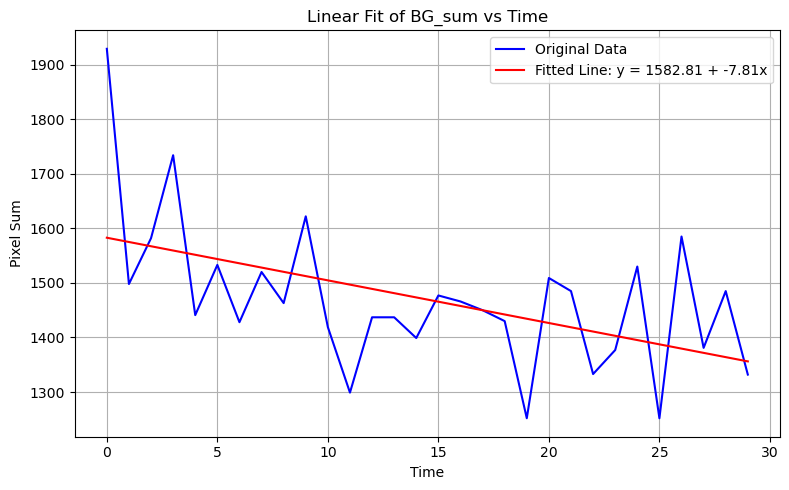

In [55]:
BG_sum = np.zeros(len(df_BG))

for i, BG in enumerate(df_BG):
    val = BG['rectangle_combined']['pixel_sum']
    BG_sum[i] = val

df = pd.read_excel(path_timefile)
time_arr = df.iloc[:, 0].to_numpy()
time_arr = time_arr[:len(BG_sum)]
print(time_arr)

a, b = LinearFit(np.array(range(len(BG_sum))), BG_sum)

# Generate fitted line
fitted_line = a + b * np.array(range(len(BG_sum)))

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(np.array(range(len(BG_sum))), BG_sum, label='Original Data', color='blue')
plt.plot(np.array(range(len(BG_sum))), fitted_line, label=f'Fitted Line: y = {a:.2f} + {b:.2f}x', color='red')
plt.xlabel('Time')
plt.ylabel('Pixel Sum')
plt.title('Linear Fit of BG_sum vs Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
def MakeSummaryRow(i, BKT, SKT, CKT, BG, a, b):
    bg_mean = BG['rectangle_combined']['pixel_sum'] / BG['rectangle_combined']['area']

    return pd.DataFrame({
        'Timepoint': [i + 1],

        'Area_BKT_unbleached': [BKT['rectangle1']['area'] * pixelsize],
        'Sum_BKT_unbleached': [BKT['rectangle1']['pixel_sum']],
        'Mean_BKT_unbleached': [BKT['rectangle1']['pixel_sum'] / BKT['rectangle1']['area']],

        'Area_BKT_bleached': [BKT['rectangle2']['area'] * pixelsize],
        'Sum_BKT_bleached': [BKT['rectangle2']['pixel_sum']],
        'Mean_BKT_bleached': [BKT['rectangle2']['pixel_sum'] / BKT['rectangle2']['area']],

        'Spacer1': [np.nan],

        'Area_SKT': [SKT['rectangle1']['area'] * pixelsize],
        'Sum_SKT': [SKT['rectangle1']['pixel_sum']],
        'Mean_SKT': [SKT['rectangle1']['pixel_sum'] / SKT['rectangle1']['area']],

        'Spacer2': [np.nan],

        'Area_CKT': [CKT['rectangle1']['area'] * pixelsize],
        'Sum_CKT': [CKT['rectangle1']['pixel_sum']],
        'Mean_CKT': [CKT['rectangle1']['pixel_sum'] / CKT['rectangle1']['area']],

        'Spacer3': [np.nan],

        'Area_BG': [BG['rectangle_combined']['area'] * pixelsize],
        'Sum_BG': [BG['rectangle_combined']['pixel_sum']],
        'Mean_BG': [bg_mean],

        'Spacer4': [np.nan],
        'Spacer5': [np.nan],

        'Unbleached_Corr': [BKT['rectangle1']['pixel_sum'] / (a + b*time_arr[i])],
        'Unbleached_Corr_Norm': [np.nan],
        'Bleached_Corr': [BKT['rectangle2']['pixel_sum']/ (a + b*time_arr[i])],
        'Bleached_Corr_Norm': [np.nan],
        'Sister_Corr': [SKT['rectangle1']['pixel_sum'] / (a + b*time_arr[i])],
        'Sister_Corr_Norm': [np.nan],
        'Control_Corr': [CKT['rectangle1']['pixel_sum'] / (a + b*time_arr[i])],
        'Control_Corr_Norm': [np.nan],
        'BG_Norm': [np.nan],
        
        'Spacer6': [np.nan],

        'UnbleachedRatio':  [np.nan],
        'BleachedROI':  [np.nan],
        'SisterROI':  [np.nan],
    })
    
def normalize_column(df, source_col, new_col, base_range=slice(0, 3)):
    mean_val = np.mean(df[source_col].iloc[base_range])
    df[new_col] = df[source_col] / mean_val
    return df

In [57]:

summary_df = []
for i, (BKT, SKT, CKT, BG) in enumerate(zip(df_BKT, df_SKT, df_CKT, df_BG)):
    
    data = MakeSummaryRow(i, BKT, SKT, CKT, BG, a, b)

    summary_df.append(data)

summary_df = pd.concat(summary_df, ignore_index=True)


normalize_column(summary_df, "Unbleached_Corr", "Unbleached_Corr_Norm")
normalize_column(summary_df, "Bleached_Corr", "Bleached_Corr_Norm")
normalize_column(summary_df, "Sister_Corr", "Sister_Corr_Norm")
normalize_column(summary_df, "Control_Corr", "Control_Corr_Norm")
normalize_column(summary_df, "Sum_BG", "BG_Norm")


summary_df["UnbleachedRatio"] = summary_df["Unbleached_Corr_Norm"] / summary_df["Control_Corr_Norm"]
summary_df.loc[:1, "UnbleachedRatio"] = np.nan
summary_df.loc[2, "UnbleachedRatio"] = 1
summary_df["BleachedROI"] = summary_df["Bleached_Corr_Norm"] / summary_df["Control_Corr_Norm"]
summary_df.loc[:1, "BleachedROI"] = np.nan
summary_df.loc[2, "BleachedROI"] = 1
summary_df["SisterROI"] = summary_df["Sister_Corr_Norm"] / summary_df["Control_Corr_Norm"]
summary_df.loc[:1, "SisterROI"] = np.nan
summary_df.loc[2, "SisterROI"] = 1

In [58]:
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter

# Save initial dataframe to Excel
excel_path = os.path.join(output_dir, f"{output_name}.xlsx")
summary_df.to_excel(excel_path, index=False, sheet_name="Summary")

# Load workbook and sheet
wb = load_workbook(excel_path)
ws = wb["Summary"]


# === Step 1: Insert a new row at the top ===
ws.insert_rows(1)

# === Step 2: Define groups and their column ranges ===
groups = {
    "Unbleached": ("B", "D", PatternFill(start_color="FFF2CC", end_color="FFF2CC", fill_type="solid")),
    "Bleached": ("E", "G", PatternFill(start_color="FDD7D7", end_color="FDD7D7", fill_type="solid")),
    "SKT": ("I", "K", PatternFill(start_color="DDEBF7", end_color="DDEBF7", fill_type="solid")),
    "CKT": ("M", "O", PatternFill(start_color="D0CECE", end_color="D0CECE", fill_type="solid")),
    "BG": ("Q", "S", PatternFill(start_color="F2F2F2", end_color="F2F2F2", fill_type="solid")),
    "Background Bleach-Correction": ("V", "AD", PatternFill(start_color="CCE5FF", end_color="CCE5FF", fill_type="solid")),
    "Ratio with Control": ("AF", "AH", PatternFill(start_color="CCE5FF", end_color="CCE5FF", fill_type="solid"))
}

# === Style settings ===
#fill = PatternFill(start_color="CCE5FF", end_color="CCE5FF", fill_type="solid")  
font = Font(bold=True, size=12)
alignment = Alignment(horizontal="center", vertical="center")

# === Step 3: Merge cells and insert group titles ===
for title, (start_col, end_col, fill) in groups.items():
    ws.merge_cells(f"{start_col}1:{end_col}1")
    cell = ws[f"{start_col}1"]
    cell.value = title
    cell.fill = fill
    cell.font = font
    cell.alignment = alignment

# === Optional: Adjust row height, styling, etc. ===
ws.row_dimensions[1].height = 24

for col in ws.columns:
    max_length = 0
    col_letter = get_column_letter(col[0].column)
    
    for cell in col:
        try:
            if cell.value:
                # Convert to string and measure length
                max_length = max(max_length, len(str(cell.value)))
        except:
            pass
    
    adjusted_width = max_length + 2  # extra padding
    ws.column_dimensions[col_letter].width = adjusted_width

# === Save the styled Excel file ===
wb.save(excel_path)


In [59]:
all_overlays_list = overlays_BKT + overlays_SKT + overlays_CKT + overlays_BG
output_overlays = os.path.join(output_dir, "overlays")
draw_all_overlays(img, all_overlays_list, output_overlays)